<a href="https://colab.research.google.com/github/mklatzke/IndividualMovieAnalysisProject/blob/main/Movie_Analysis_Klatzke.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
file_path = '/content/drive/MyDrive/movies_dataset.csv' # Paste your path here using the Files tab on the left hand side
movies = pd.read_csv(file_path)

In [39]:
# preview of relevant dataset columns
movies[['Title', 'ReleaseYear', 'US_BoxOfficeUSD', 'Opening_Day_SalesUSD']].head()

,Title,ReleaseYear,US_BoxOfficeUSD,Opening_Day_SalesUSD
0,Might toward capital,2003,6613685.82,1778530.85
1,He however experience,1988,1930949.15,247115.74
2,Star responsibility politics,1971,4186694.69,878453.95
3,Exactly live,1998,2023683.92,570657.72
4,Focus improve especially,2021,2129629.10,361189.37


# 1. Are movies released in odd-numbered years more profitable than movies from even-numbered years?

In [40]:
from scipy import stats
# categorize release dates by odd or even year
movies['YearsOddEven'] = movies['ReleaseYear'] % 2 # new column where even years = 0 and odd = 1
movies['YearsOddEven'] = movies['YearsOddEven'].map({0: 'Even', 1: 'Odd'}) # change labels to Even or Odd
even_revenue = movies[movies['YearsOddEven'] == 'Even']['Global_BoxOfficeUSD']
odd_revenue = movies[movies['YearsOddEven'] == 'Odd']['Global_BoxOfficeUSD']

# run two-sample t-test
t_stat, p_value = stats.ttest_ind(even_revenue, odd_revenue)
print(p_value)

0.4710319611283329


The null hypothesis in a two-sample t-test is that there is no difference between the means of the groups. This test compares the mean global box offices between movies released in odd and even years. The p-value is 0.4710319611283329, so the test fails to reject the null hypothesis. There is no statistical difference between the average revenue of movies released in odd-numbered years and even-numbered years.

/tmp/ipykernel_4319/3011509925.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([even_revenue / 1000000000, odd_revenue / 1000000000], labels=['Even Release Years', 'Odd Release Years'], vert = False)


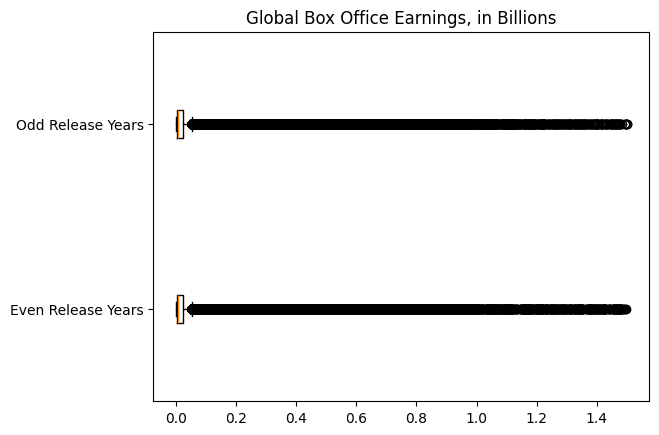

In [41]:
import matplotlib.pyplot as plt
# visualize results
plt.boxplot([even_revenue / 1000000000, odd_revenue / 1000000000], labels=['Even Release Years', 'Odd Release Years'], vert = False)
plt.title('Global Box Office Earnings, in Billions')
plt.show()

# 2. How much of the total box office gross comes from opening day ticket sales?

Text(0.5, 1.0, 'US Total Box Office USD')

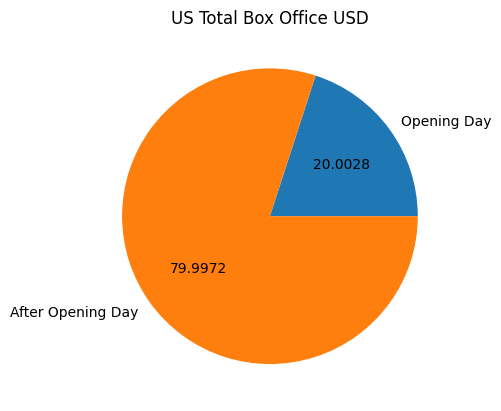

In [33]:
# calculate difference between total US and opening day US averages
movies['US_AfterOpeningDay'] = movies['US_BoxOfficeUSD'] - movies['Opening_Day_SalesUSD']
avg_US_AfterOpeningDay = movies['US_AfterOpeningDay'].mean()
avg_OpeningDaySales = movies['Opening_Day_SalesUSD'].mean()

# pie chart for visualization
plt.pie([avg_OpeningDaySales, avg_US_AfterOpeningDay], labels = ['Opening Day', 'After Opening Day'], autopct='%.4f')
plt.title('US Total Box Office USD')

Opening day ticket sales make up ~20 percent of all US first-week box office earnings. This is a significant amount of profit to make all in the first day.